In [1]:
import os
import shutil

for path in [
    "/content/Project_GNN",
    "/content/generated_crops_fewshot",
]:
    if os.path.exists(path):
        shutil.rmtree(path)

print("Cleaned.")

Cleaned.


clone repo và cài thư viện

In [3]:
!git clone https://github.com/2274802010922/Project_GNN.git /content/Project_GNN
%cd /content/Project_GNN
!pip install -q -r requirements.txt

Cloning into '/content/Project_GNN'...
remote: Enumerating objects: 401, done.
remote: Counting objects: 100% (113/113), done.
remote: Compressing objects: 100% (98/98), done.
remote: Total 401 (delta 55), reused 15 (delta 15), pack-reused 288 (from 2)
Receiving objects: 100% (401/401), 3.22 MiB | 15.35 MiB/s, done.
Resolving deltas: 100% (188/188), done.
/content/Project_GNN
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 92.4 MB/s eta 0:00:00


kiểm tra loader trước khi train

In [5]:
from dataset import download_dataset, load_image_paths_and_labels

dataset_path = download_dataset()
image_paths, labels, class_names, source = load_image_paths_and_labels(dataset_path)

print("SOURCE:", source)
print("NUM SAMPLES:", len(image_paths))
print("NUM CLASSES:", len(class_names))
print("FIRST 10 CLASSES:", class_names[:10])
print("FIRST 5 PATHS:", image_paths[:5])

100%|██████████| 240M/240M [00:01<00:00, 153MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/anhduy091100/vaipe-minimal-dataset/versions/1
Crop output directory: /content/generated_crops_fewshot
Label source: vaipe_json_boxes
Total cropped instances: 312
Total classes after filtering (>= 2 samples/class): 59
Top classes by sample count:
  Hoat-Huyet-Duong-Nao: 34
  Tatanol-500mg-VBP: 28
  Amoxicillin-500mg: 26
  Partamol-500mg: 20
  Alpha-Chymotrypsine: 13
  Droxicef-500mg: 13
  Flagyl-250mg: 10
  Panadol-500mg: 9
  Colchicin-1mg: 8
  Cephalexin-500mg: 7
  Enalapril-5mg: 7
  Acetaminophen: 7
  Amlodipine-5mg: 5
  Vitamin-3B: 5
  Piracetam-800mg: 5
  Clorpheniramin-4mg: 5
  Halixol: 4
  Acetylcysteine: 4
  Loratadine-10mg: 4
  LIVOLIN-FORTE: 4
SOURCE: vaipe_json_boxes
NUM SAMPLES: 312
NUM CLASSES: 59
FIRST 10 CLASSES: ['Acetaminophen', 'Acetylcysteine', 'Agifuros-40mg', 'Agilodin-10mg', 'Allopurinol-STELLA-300mg', 'Alpha-Chymotrypsine', 'Amlodipine-5mg', 'Amoxicillin-500mg', 'Atorvastatin-10mg', 'Boganic-Forte-Vien-Nang']
F

chạy pipeline

In [6]:
!python main.py


===== STEP 1: DOWNLOAD DATASET =====
Using Colab cache for faster access to the 'vaipe-minimal-dataset' dataset.
Dataset downloaded to: /kaggle/input/vaipe-minimal-dataset

===== STEP 2: LOAD IMAGE PATHS + LABELS =====
Crop output directory: /content/generated_crops_fewshot
Label source: vaipe_json_boxes
Total cropped instances: 312
Total classes after filtering (>= 2 samples/class): 59
Top classes by sample count:
  Hoat-Huyet-Duong-Nao: 34
  Tatanol-500mg-VBP: 28
  Amoxicillin-500mg: 26
  Partamol-500mg: 20
  Alpha-Chymotrypsine: 13
  Droxicef-500mg: 13
  Flagyl-250mg: 10
  Panadol-500mg: 9
  Colchicin-1mg: 8
  Cephalexin-500mg: 7
  Enalapril-5mg: 7
  Acetaminophen: 7
  Amlodipine-5mg: 5
  Vitamin-3B: 5
  Piracetam-800mg: 5
  Clorpheniramin-4mg: 5
  Halixol: 4
  Acetylcysteine: 4
  Loratadine-10mg: 4
  LIVOLIN-FORTE: 4
Loaded label source: vaipe_json_boxes
Num samples: 312 | Num classes: 59

===== STEP 3: EXTRACT FEATURES =====
Downloading: "https://download.pytorch.org/models/resne

xem thư mục output

In [7]:
import os
out_dir = "/content/Project_GNN/outputs"
print(sorted(os.listdir(out_dir)) if os.path.exists(out_dir) else "No outputs folder")

['class_distribution.png', 'confusion_matrix.png', 'degree_distribution.png', 'explainer_edge_importance.png', 'explanation_subgraph.png', 'fewshot_gnn.pt', 'graph_with_images.png', 'interactive_graph.html', 'resnet50_tta_features.npy', 'similarity_distribution.png', 'training_curves.png', 'tsne_embeddings.png']


hiện các hình chính


--- class_distribution.png ---


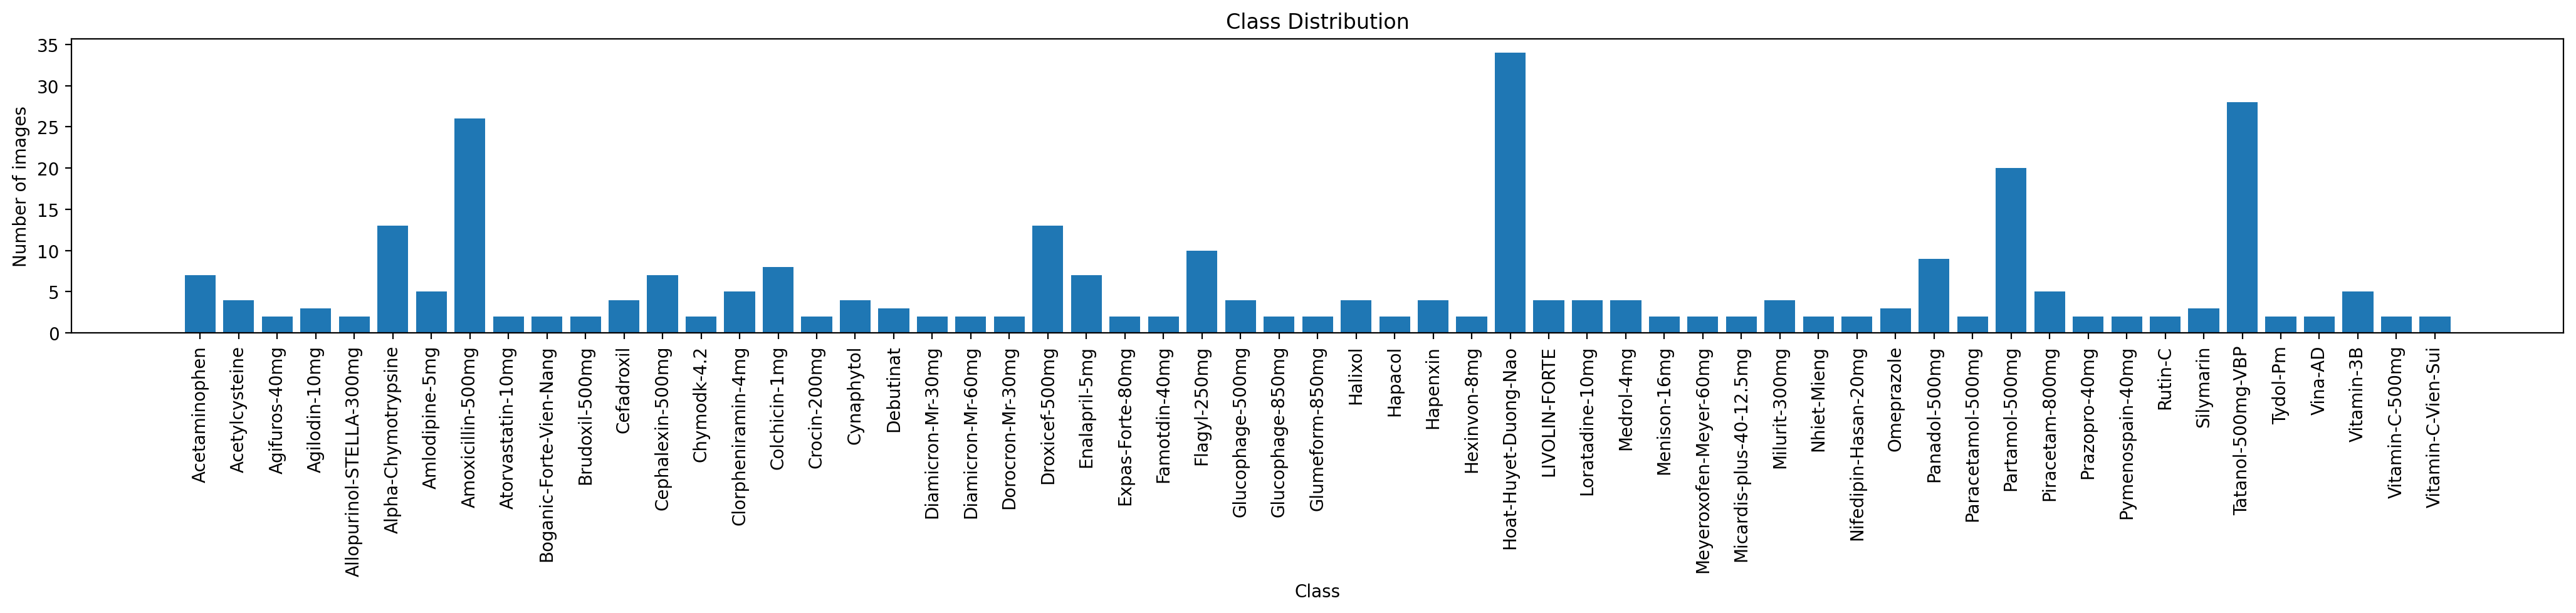


--- degree_distribution.png ---


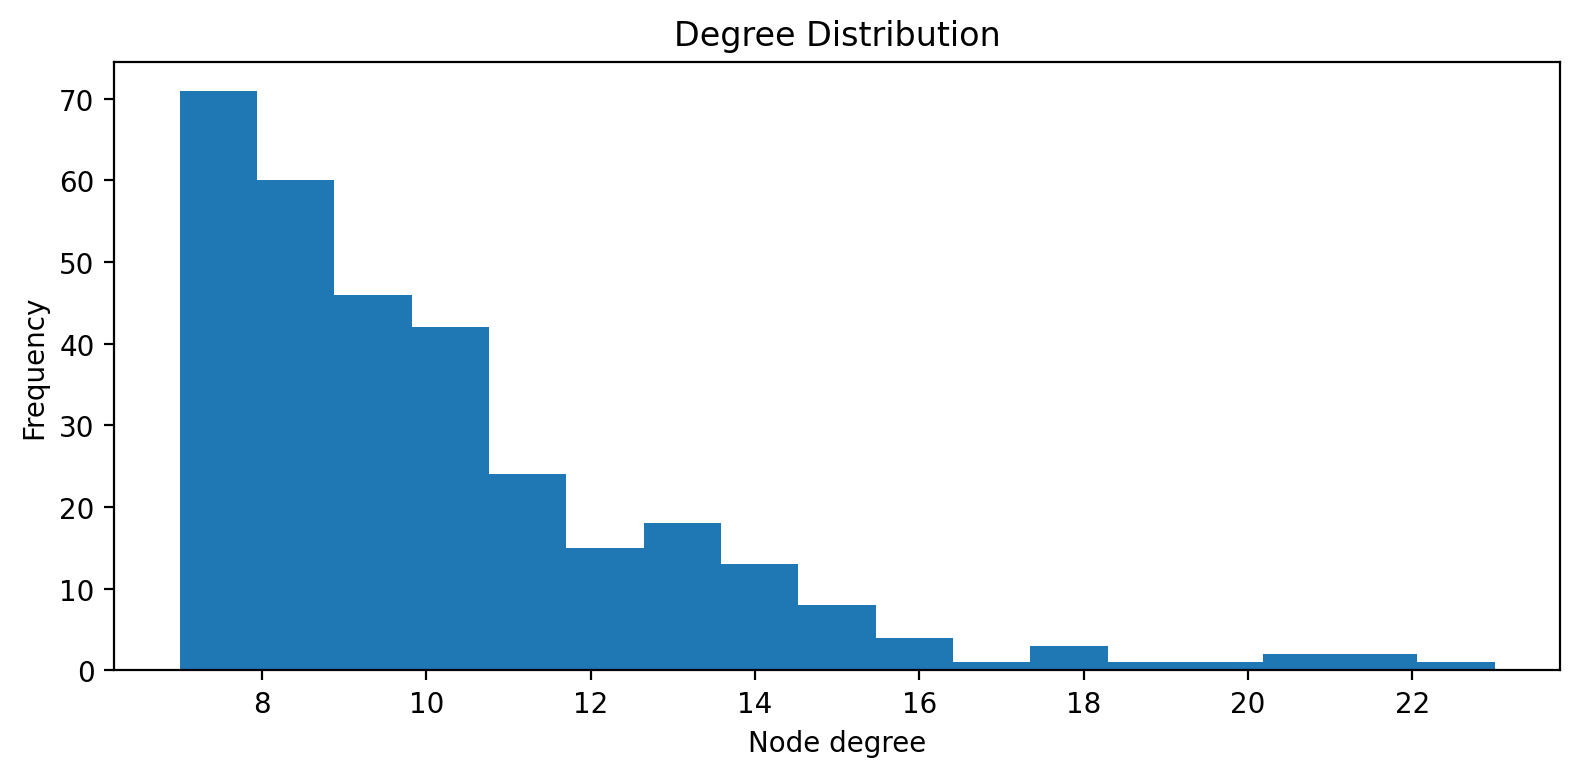


--- similarity_distribution.png ---


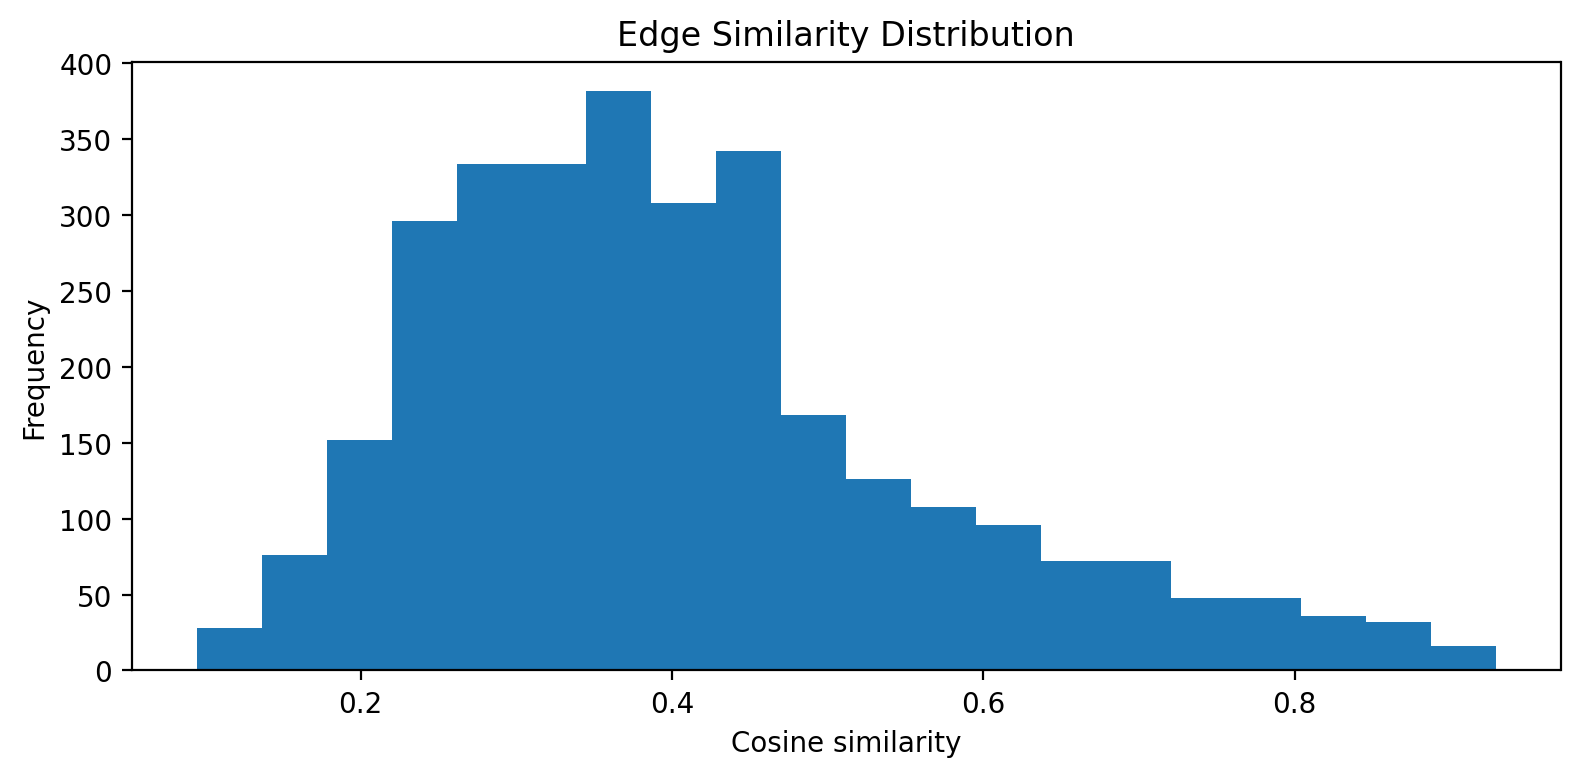


--- training_curves.png ---


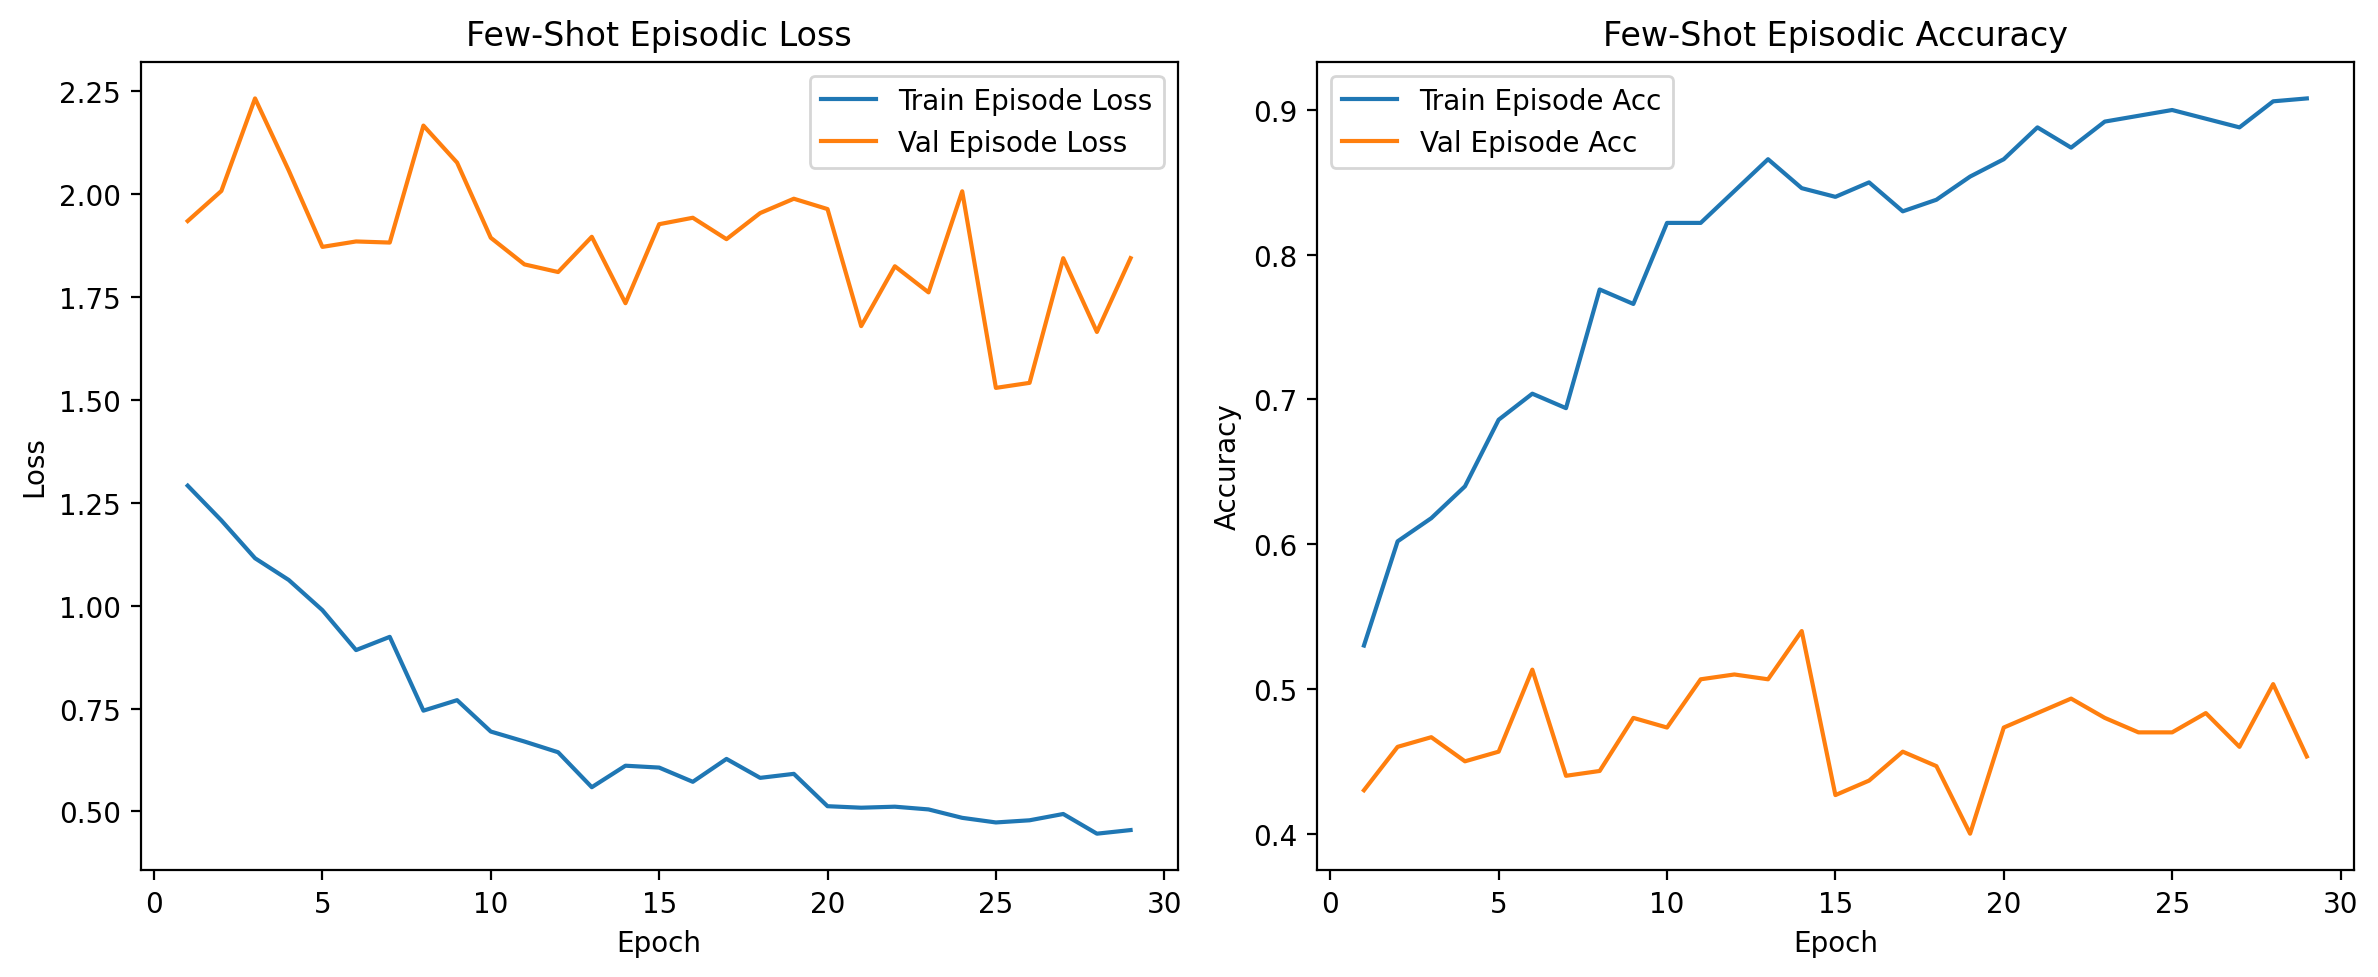


--- confusion_matrix.png ---


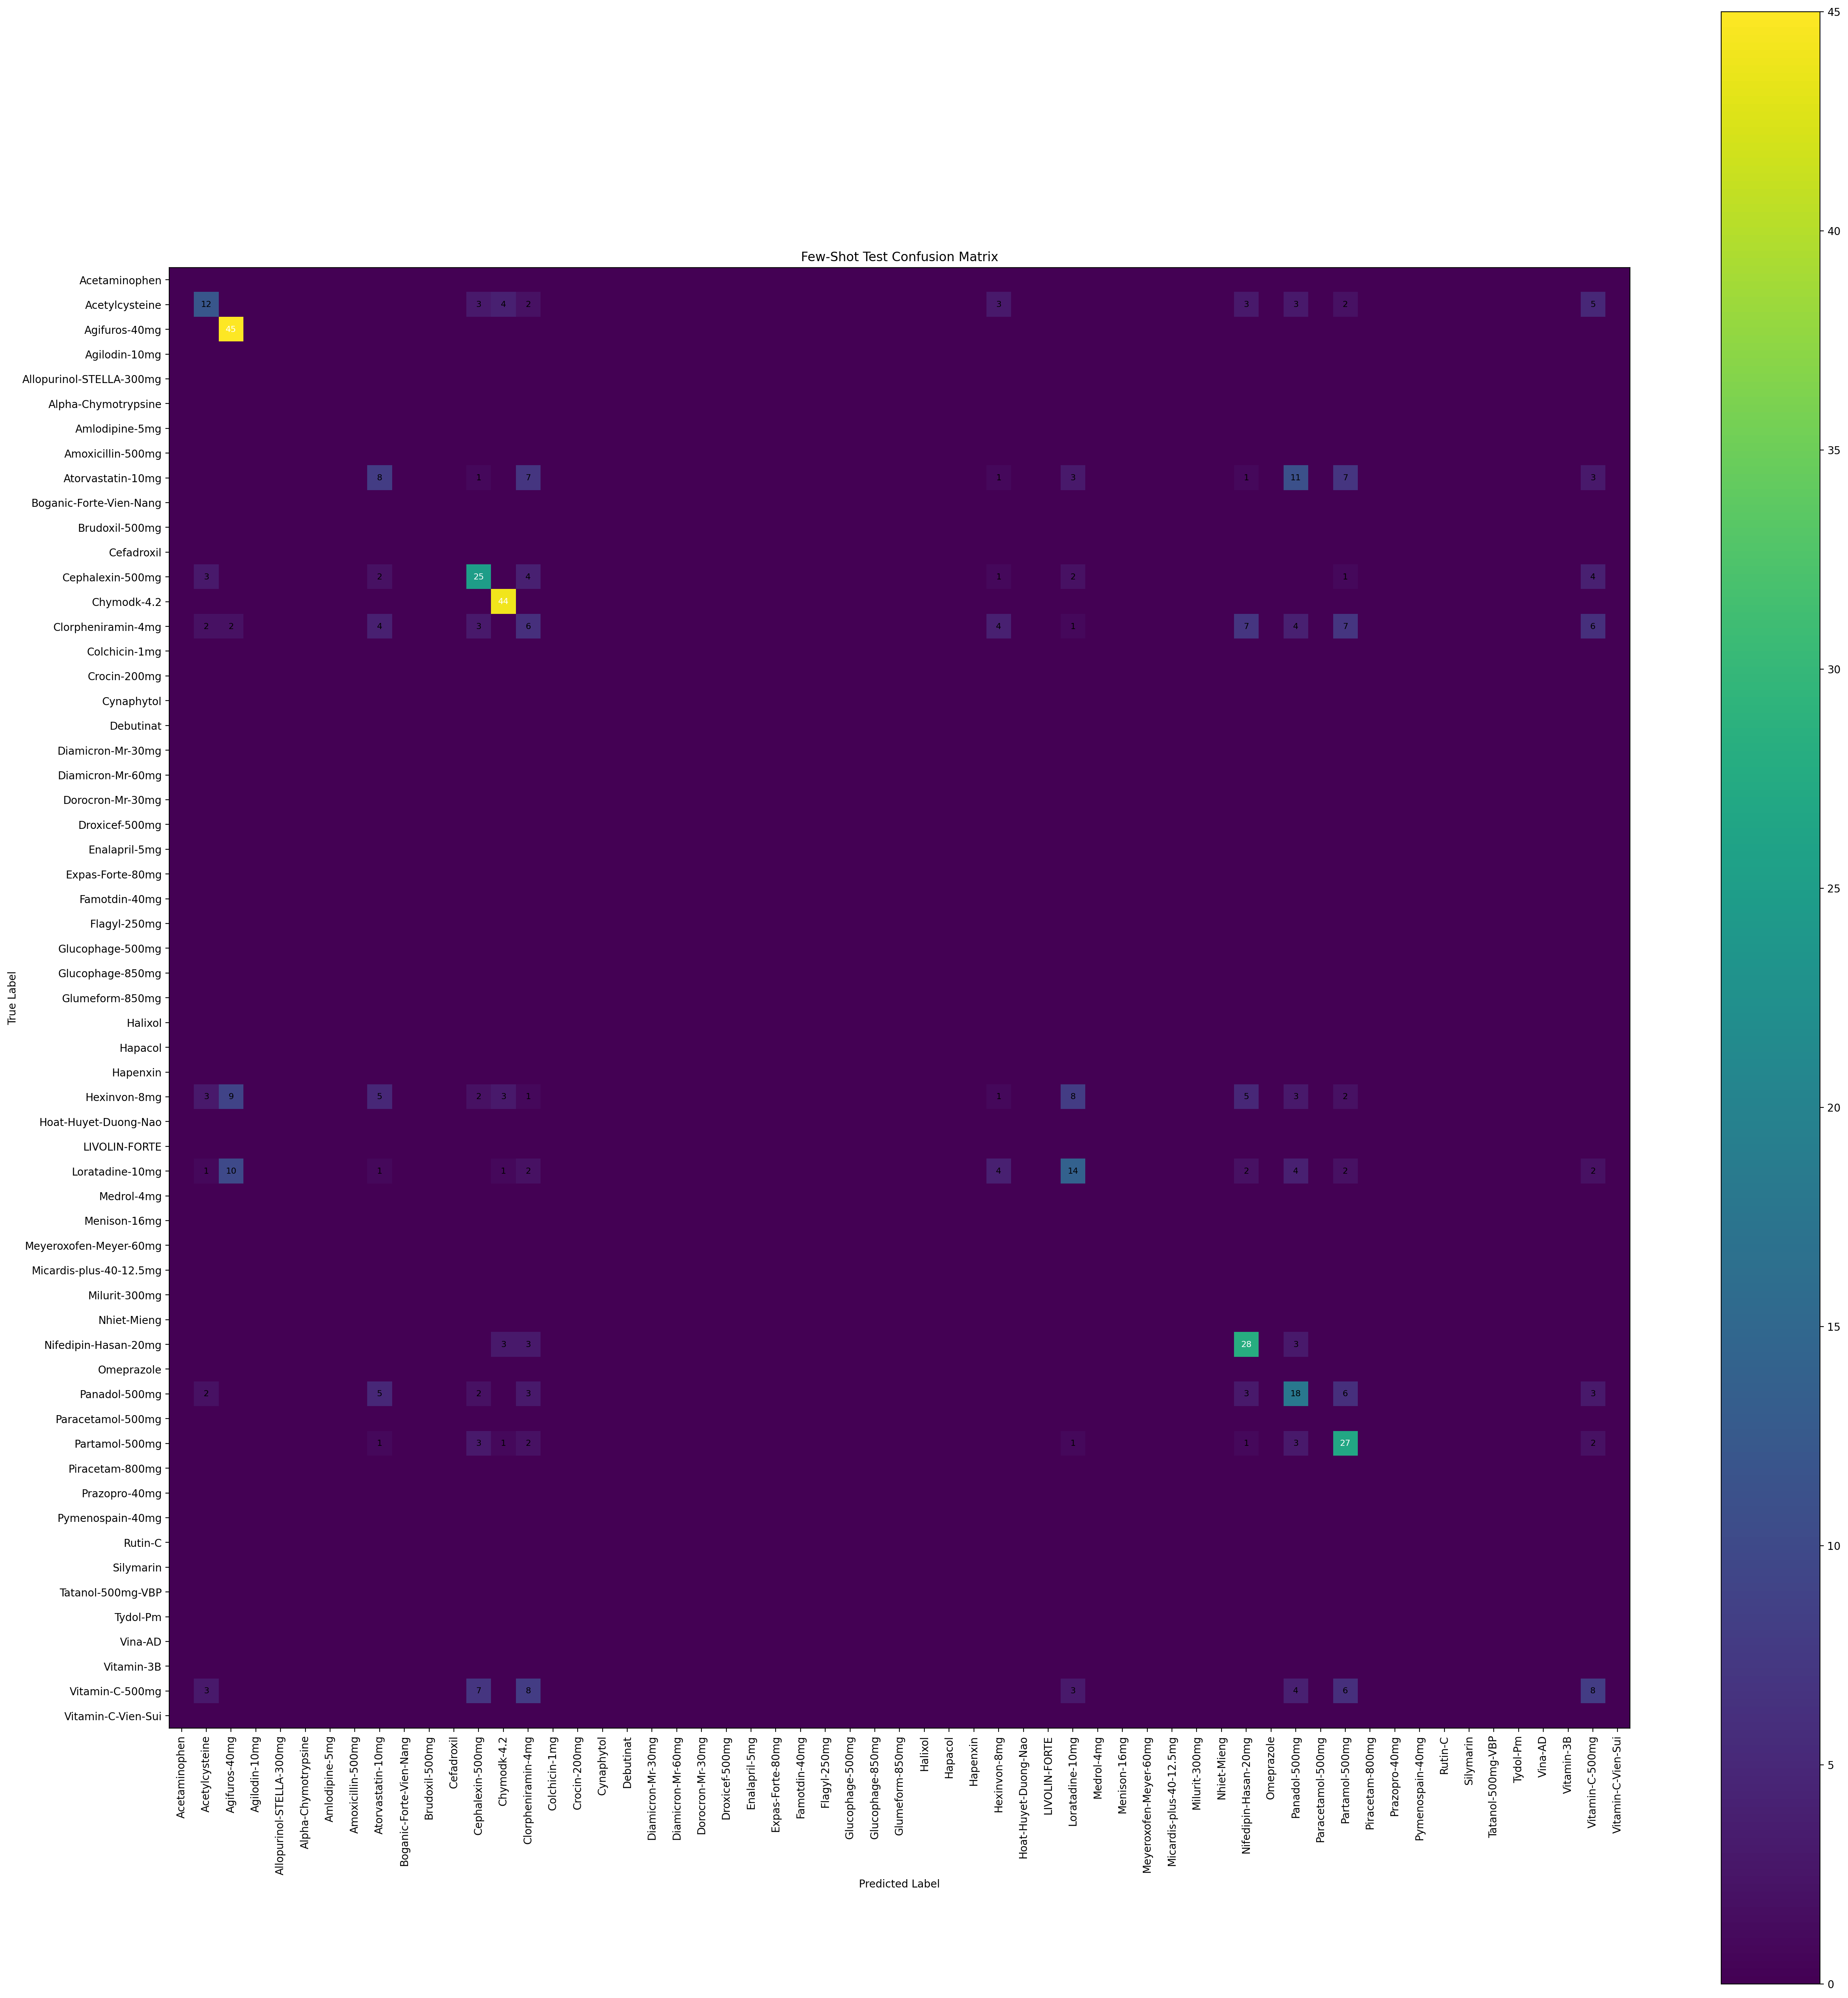


--- tsne_embeddings.png ---


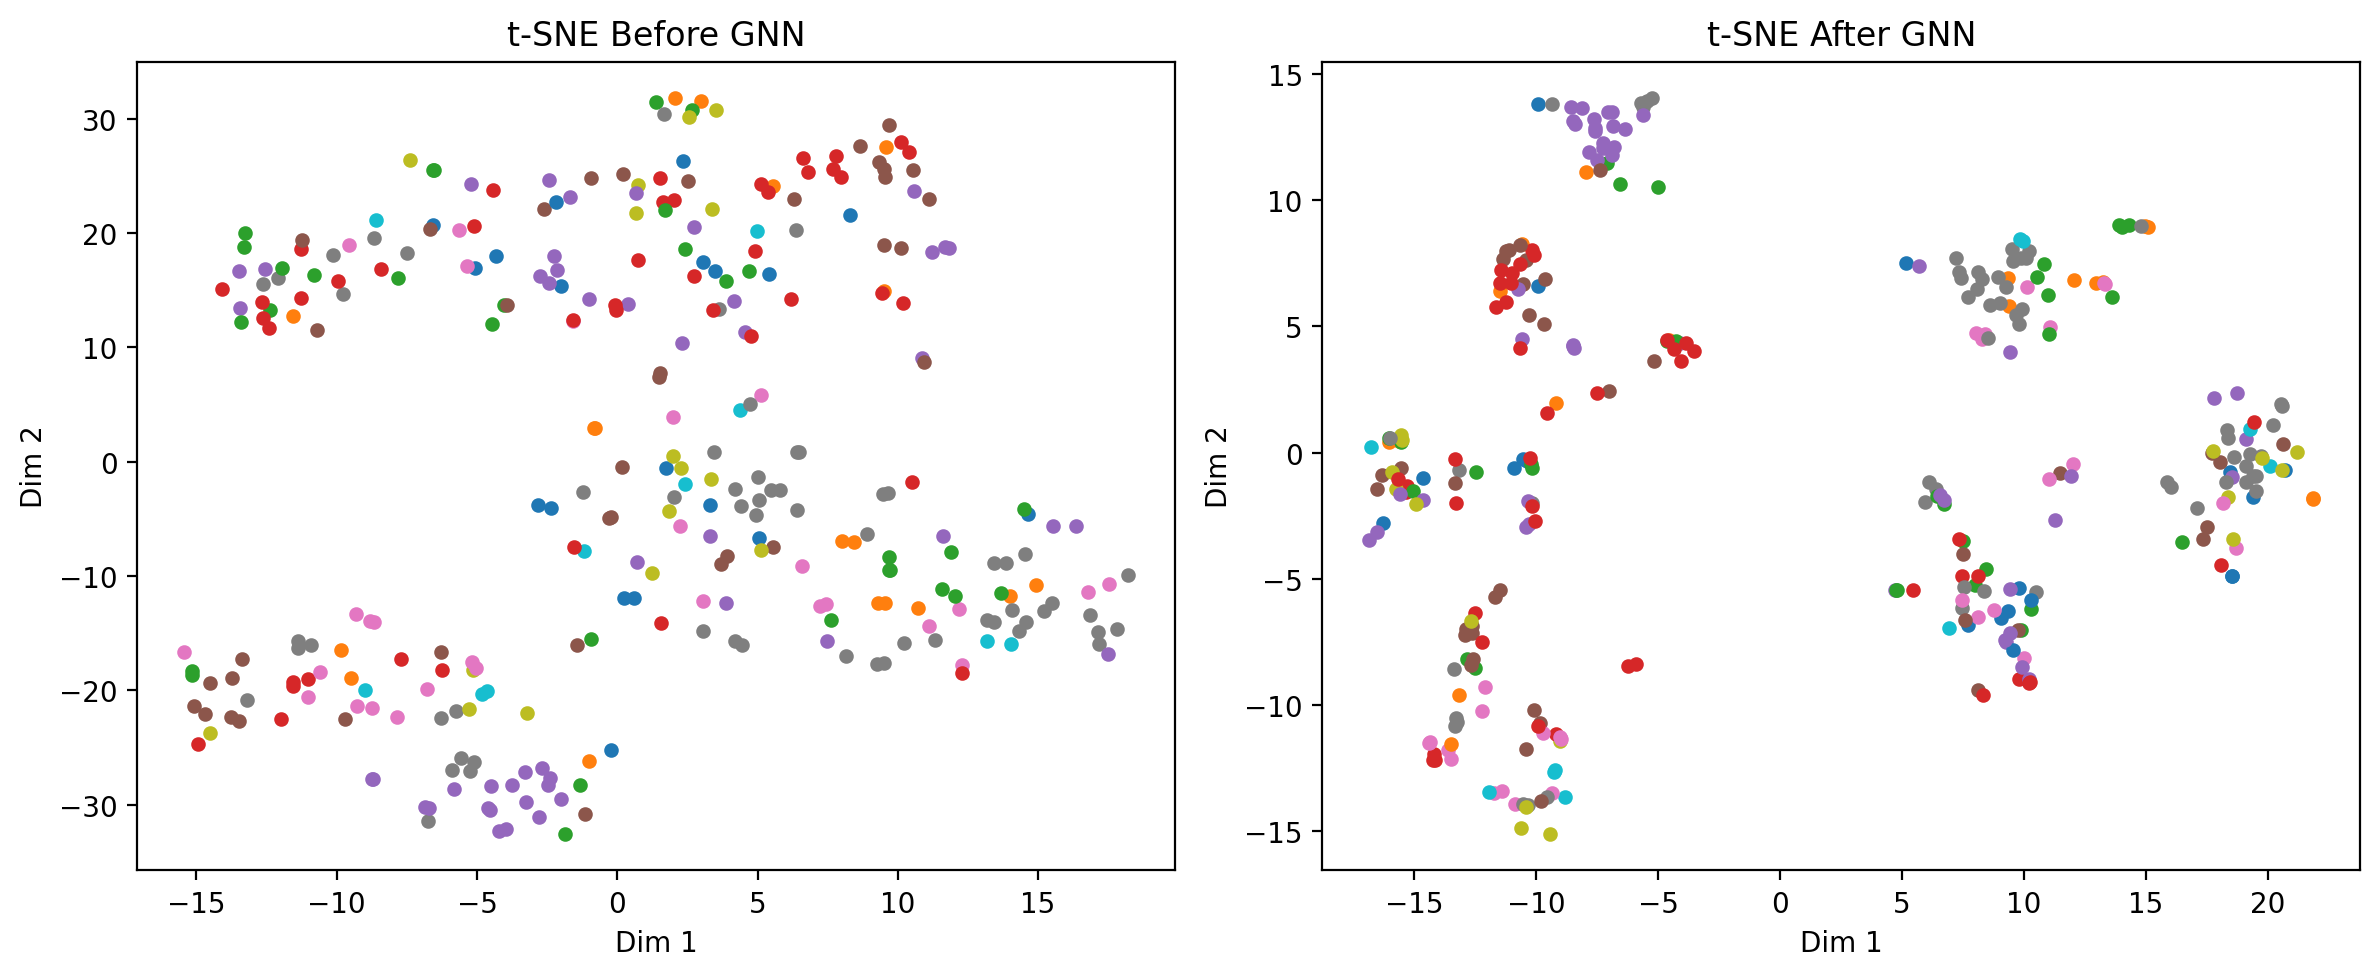


--- graph_with_images.png ---


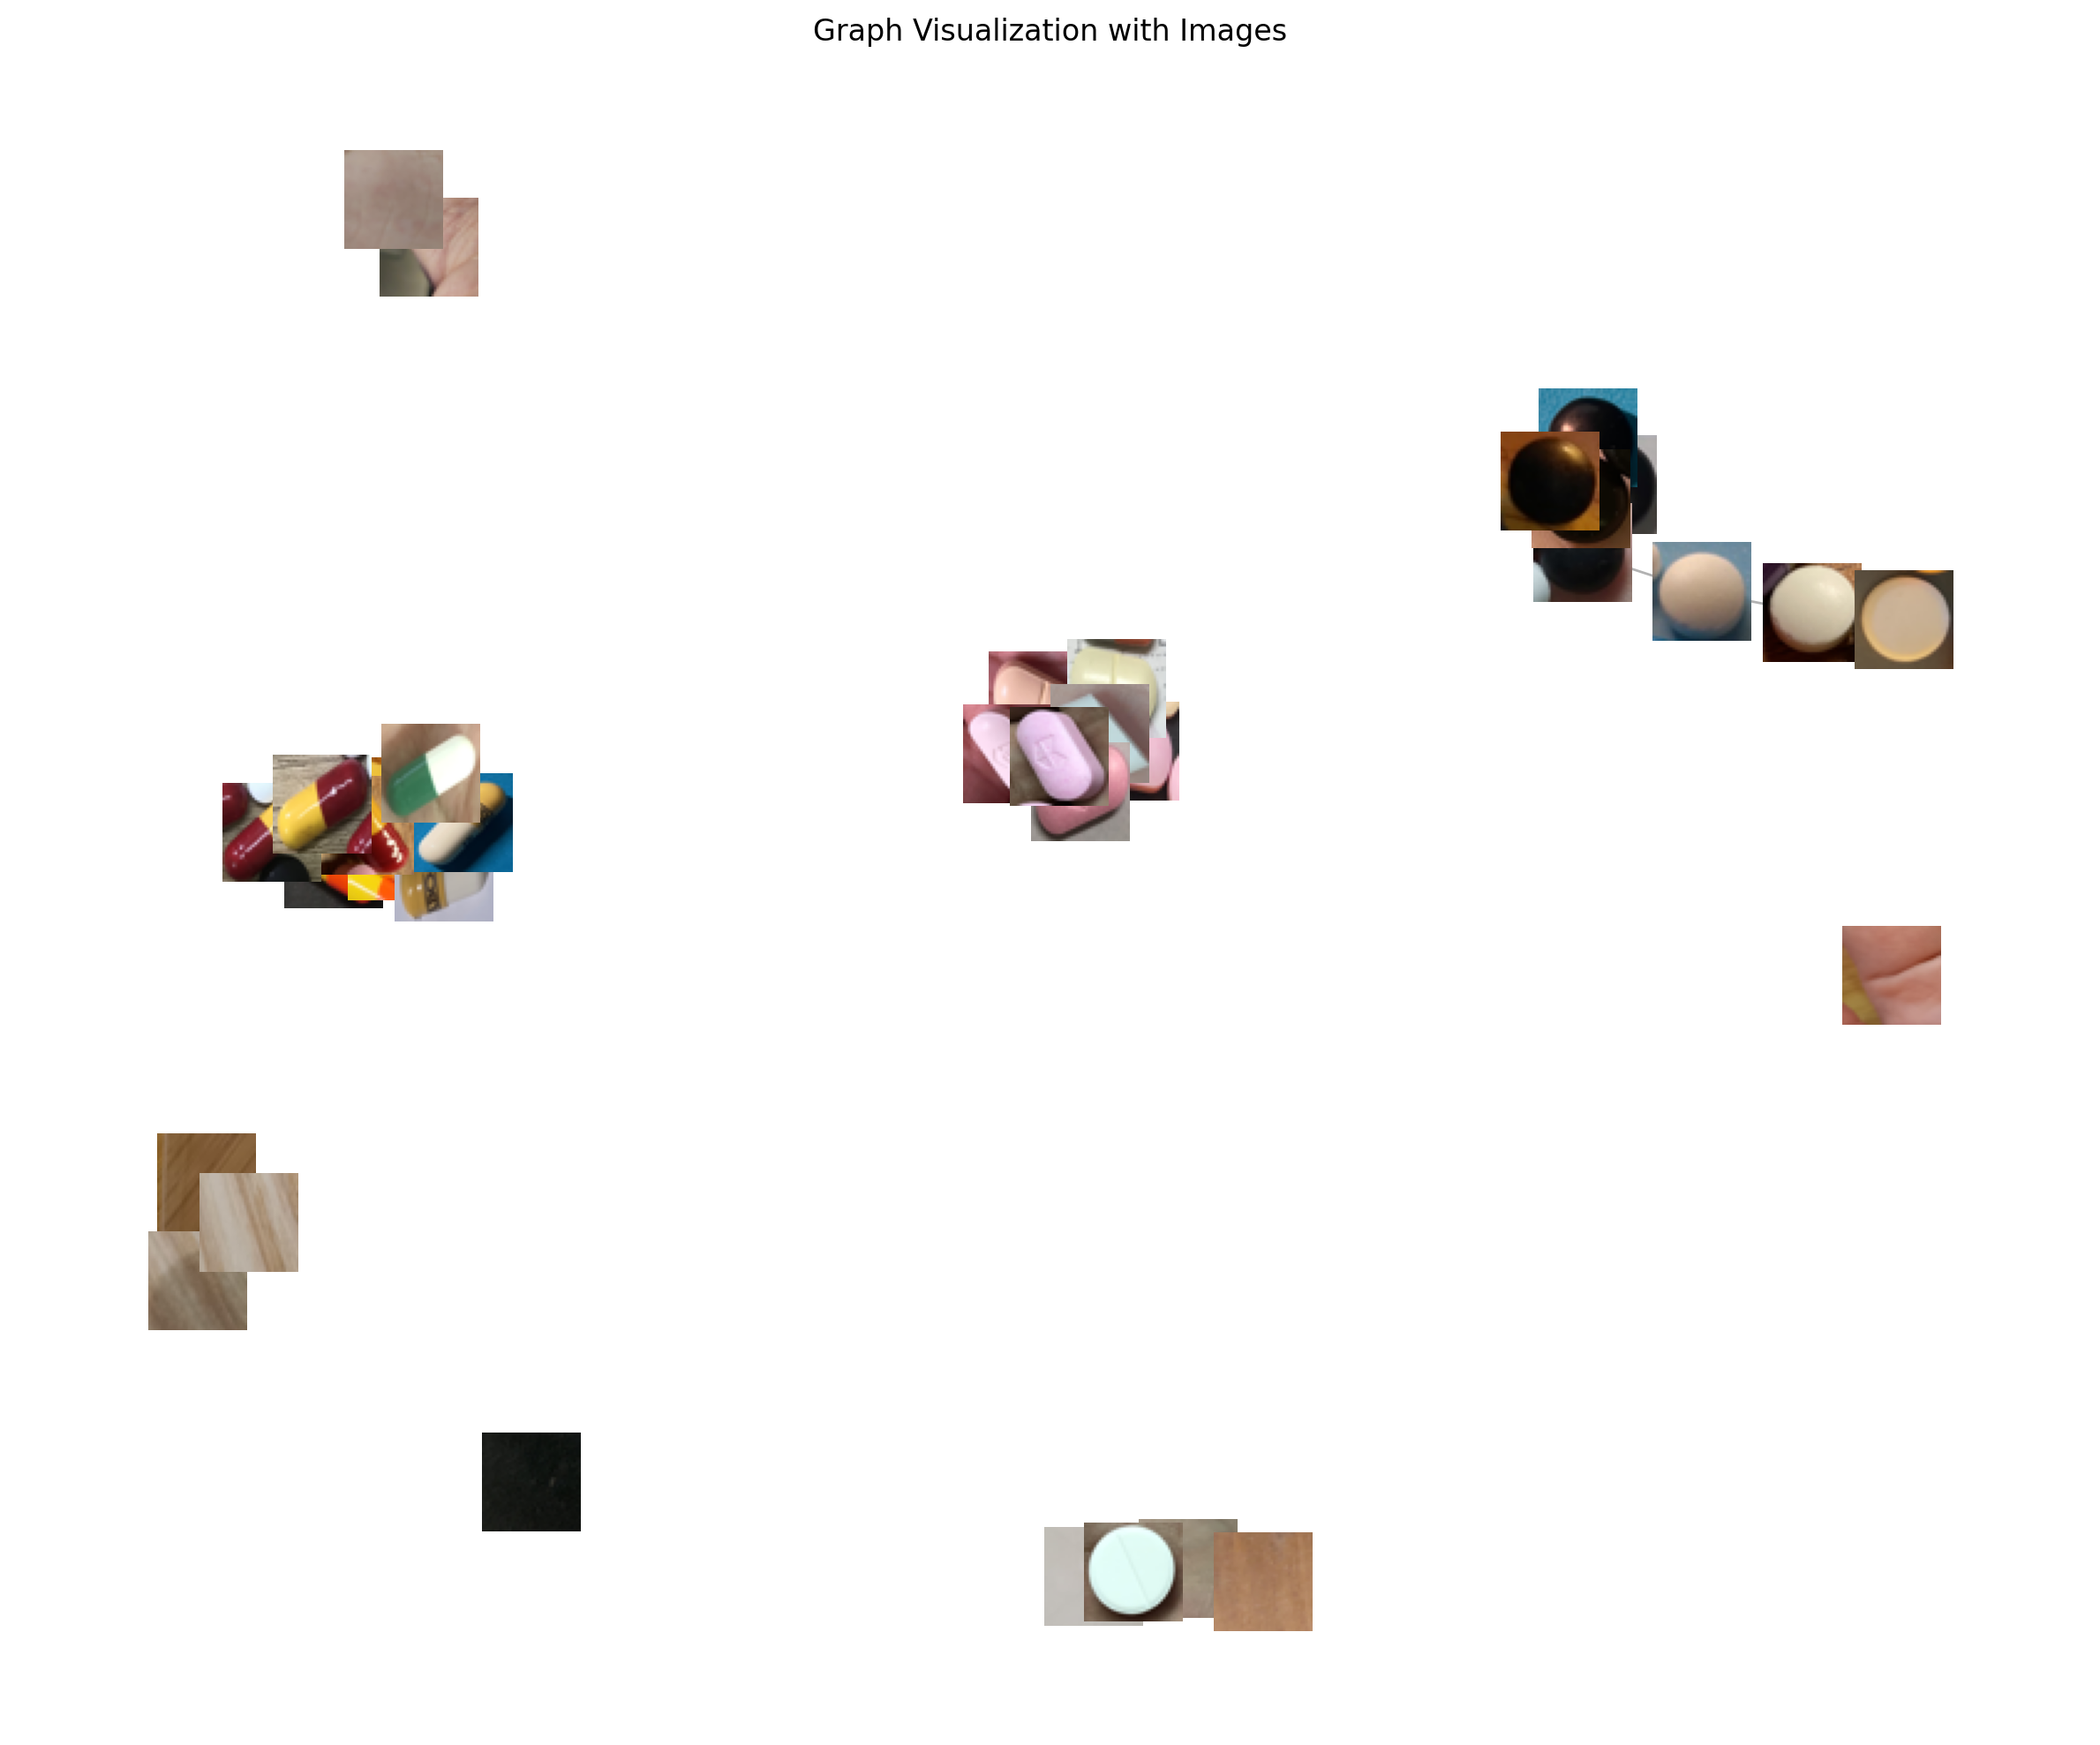


--- explainer_edge_importance.png ---


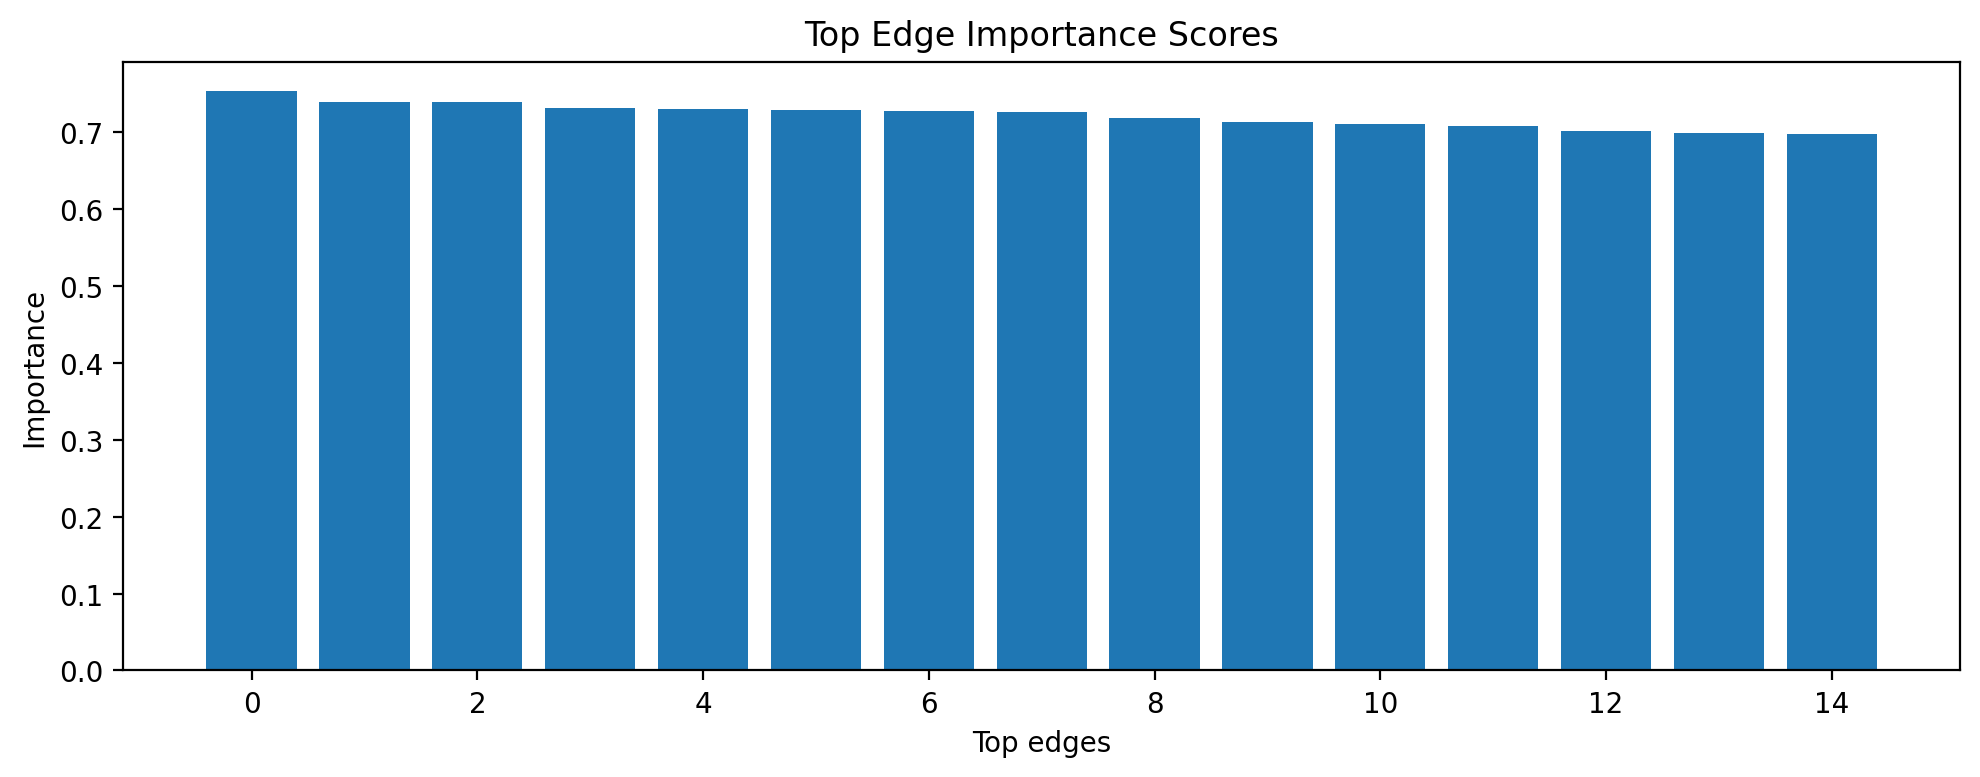


--- explanation_subgraph.png ---


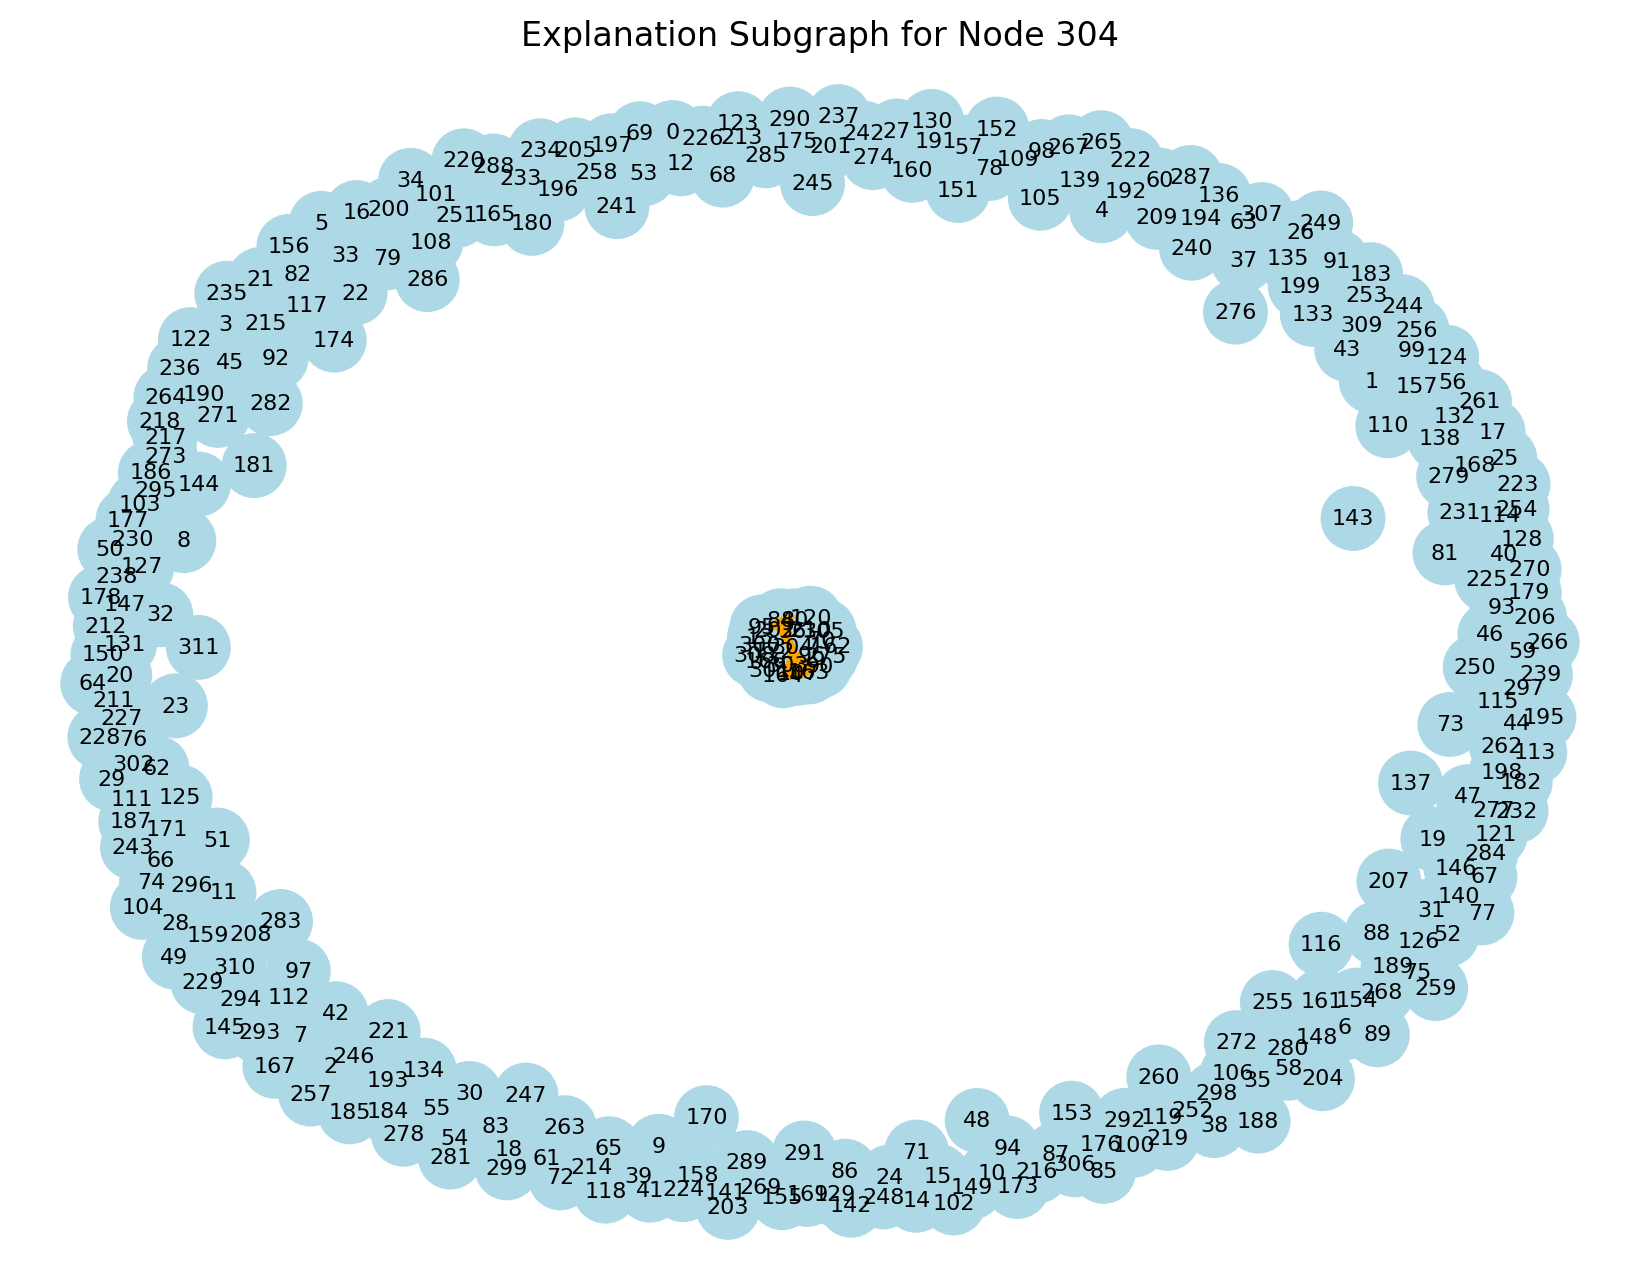

In [8]:
from IPython.display import Image, display
import os

files_to_show = [
    "class_distribution.png",
    "degree_distribution.png",
    "similarity_distribution.png",
    "training_curves.png",
    "confusion_matrix.png",
    "tsne_embeddings.png",
    "graph_with_images.png",
    "explainer_edge_importance.png",
    "explanation_subgraph.png",
]

for f in files_to_show:
    p = f"/content/Project_GNN/outputs/{f}"
    if os.path.exists(p):
        print(f"\n--- {f} ---")
        display(Image(filename=p))

mở graph tương tác

In [10]:
from IPython.display import HTML, display

html_path = "/content/Project_GNN/outputs/interactive_graph.html"

with open(html_path, "r", encoding="utf-8") as f:
    html_content = f.read()

display(HTML(html_content))